In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

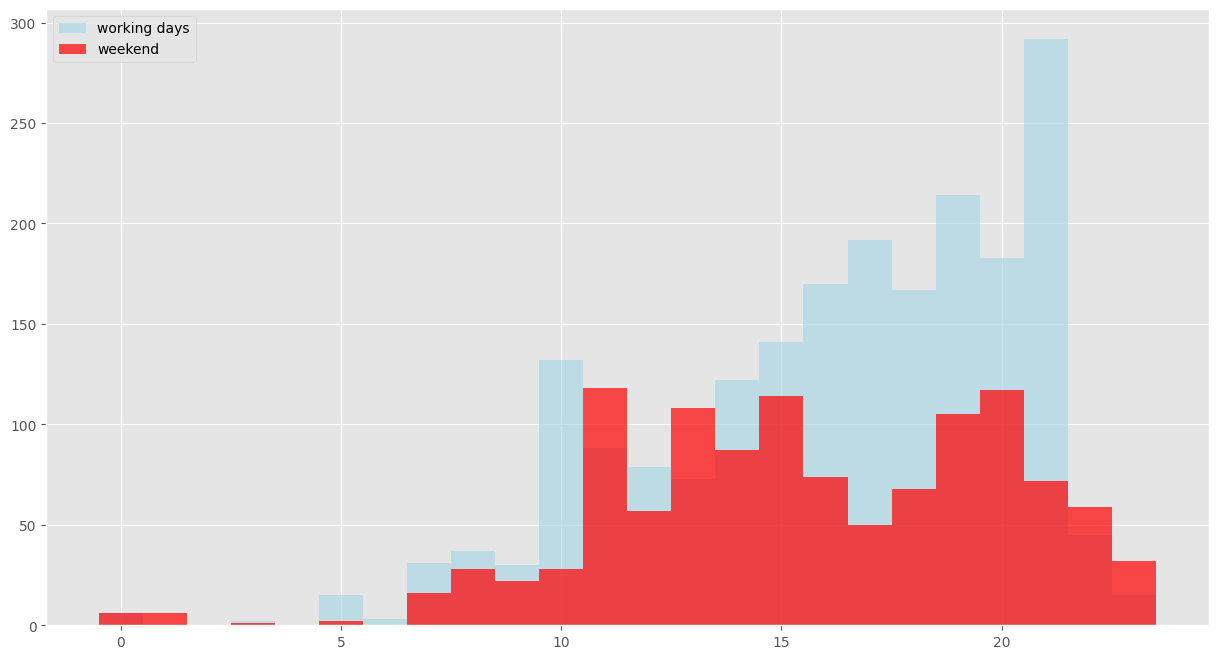

In [3]:
query = '''
SELECT
    TIME(timestamp) as time,
    DATE(timestamp) as date
FROM 
    checker
WHERE 
    uid LIKE 'user%'
'''

df = pd.read_sql_query(query, conn)

df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')
df['time'] = df['time'].dt.hour
df['is_weekend'] = df['date'].dt.weekday >= 5

grouped = df.groupby(['time', 'date', 'is_weekend']).size().reset_index(name='count_commits')

count_grouped_weekday = grouped[grouped['is_weekend'] == False].groupby('time')['count_commits'].sum().reset_index(name='count_commits')
count_grouped_weekend = grouped[grouped['is_weekend'] == True].groupby('time')['count_commits'].sum().reset_index(name='count_commits')


plt.style.use('ggplot')
plt.figure(figsize=(15, 8))
plt.bar(count_grouped_weekday['time'], count_grouped_weekday['count_commits'], color = 'lightblue', width=1, alpha=0.7, label = 'working days')
plt.bar(count_grouped_weekend['time'], count_grouped_weekend['count_commits'], color = 'red', width=1, alpha=0.7, label = 'weekend')
plt.legend()
plt.show()


## Answer: 11, 13, 22, 23 hours

In [4]:
conn.close()